# 04 — Amplitude Analysis (+ extension/compression asymmetry)

Raw **displacement and strain amplitudes** per configuration — reference
values for the numerical simulations — plus the new **extension vs
compression** investigation.

Quantities (from `ldv_analysis/amplitude.py`, `'fd'` estimator by default):

| Value | Symbol | Key |
|---|---|---|
| Endpoint relative displacement | $\Delta u_\mathrm{ends}$ | `disp_ends` |
| Endpoint strain | $\varepsilon_\mathrm{ends}$ | `strain_ends` |
| Shaker input displacement | $\delta L$ | `disp_shaker` |
| First cable-sensor displacement | $u_{\parallel,\mathrm{first}}$ | `disp_first` |
| Shaker → first-sensor transfer | $T$ | `transfer_first` |

| § | Content |
|---|---|
| 1 | Parameters, loading, geometry |
| 2 | Amplitude sweeps |
| 3 | Configuration overview (<25 Hz band means) + table |
| 4 | Amplitude vs frequency |
| 5 | Shaker input vs first sensor |
| 6 | **Extension vs compression asymmetry** |
| 7 | Export → `results/amplitude_reference.npz`, `results/asymmetry.npz` |

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Editable reload while iterating on the package
%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, analysis, plotting, export

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.2,
})
print(f"{len(la.ALL_DATASETS)} datasets in catalogue.")

46 datasets in catalogue.


---
## § 1  Parameters, loading, geometry

In [3]:
from ldv_analysis import amplitude, asymmetry, widgets

F_MIN_LOW, F_MAX_LOW = 1.0, 25.0        # quasi-static band for overviews
AMP_METHOD = 'fd'                        # 'fd' | 'median' | 'peak' | 'rms'
AMP_FREQS = list(np.arange(1, 500, 2))   # dense grid — cheap with 'fd'

ACTIVE_LABELS = None                     # None -> all sweep datasets
labels = config.SWEEP_LABELS if ACTIVE_LABELS is None else ACTIVE_LABELS
DATASETS = config.select_datasets(labels)

for cfg in DATASETS:
    io.load_cable_dataset(cfg, verbose=False)
    analysis.prepare_geometry(cfg, sag_use_3d=True, sag_use_parabola=True)
print(f"{len(DATASETS)} datasets ready.")

42 datasets ready.


---
## § 2  Amplitude sweeps

In [4]:
import time
t0 = time.time()
for cfg in DATASETS:
    amplitude.amplitude_sweep(cfg, freqs=AMP_FREQS, amp_method=AMP_METHOD)
print(f"amplitude sweeps done in {time.time()-t0:.1f} s")

amplitude sweeps done in 3.7 s


---
## § 3  Configuration overview (band means < 25 Hz)

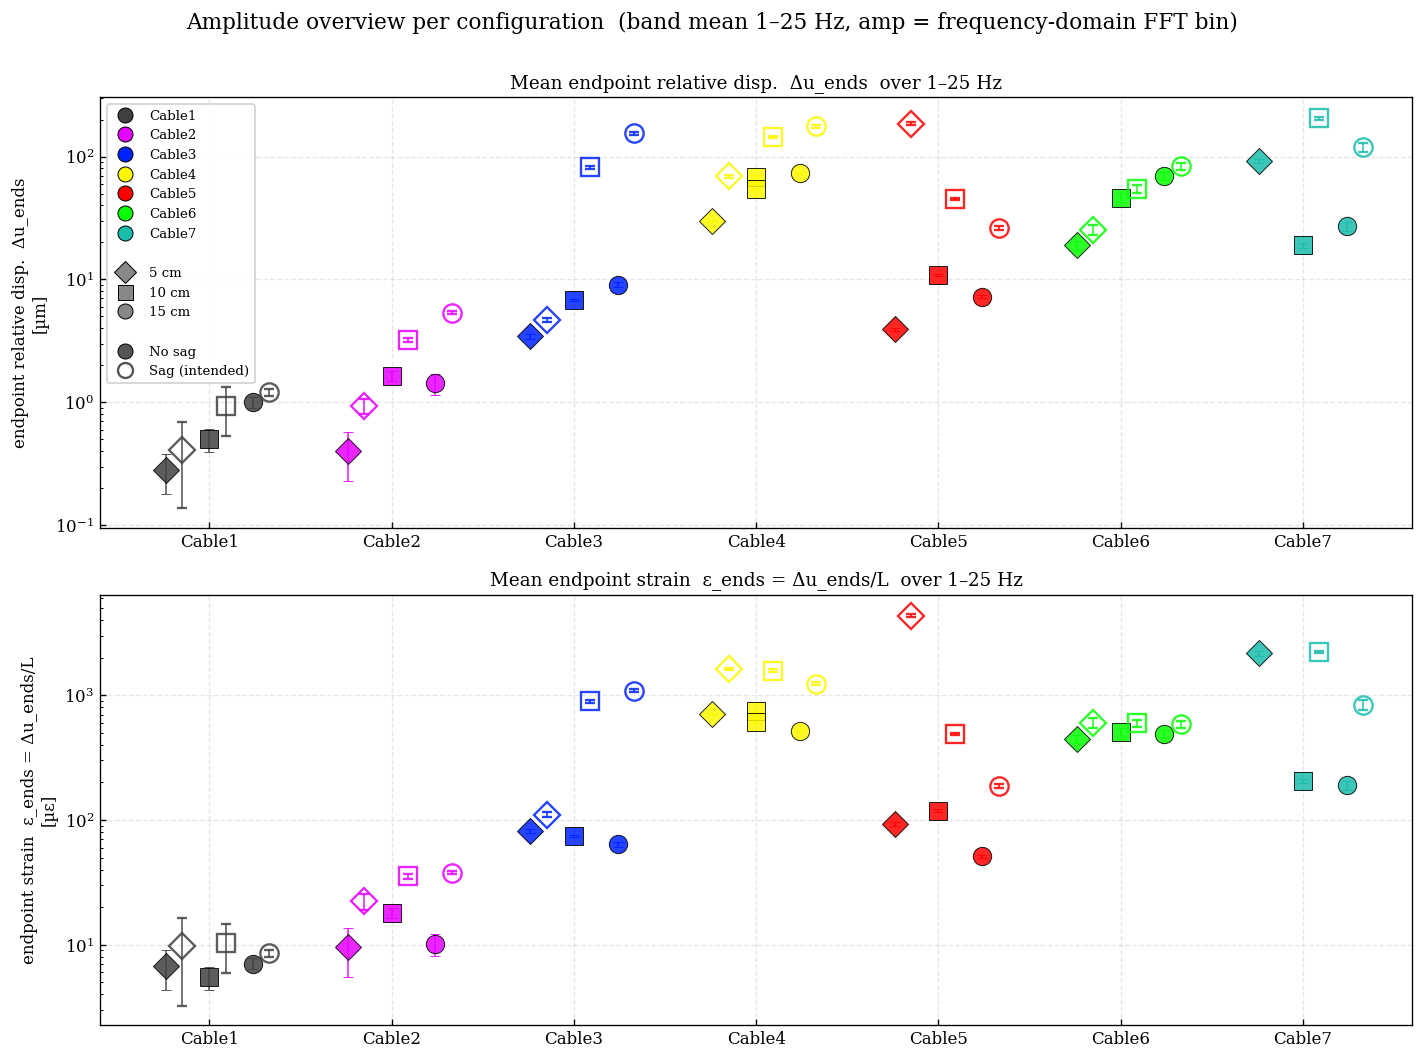

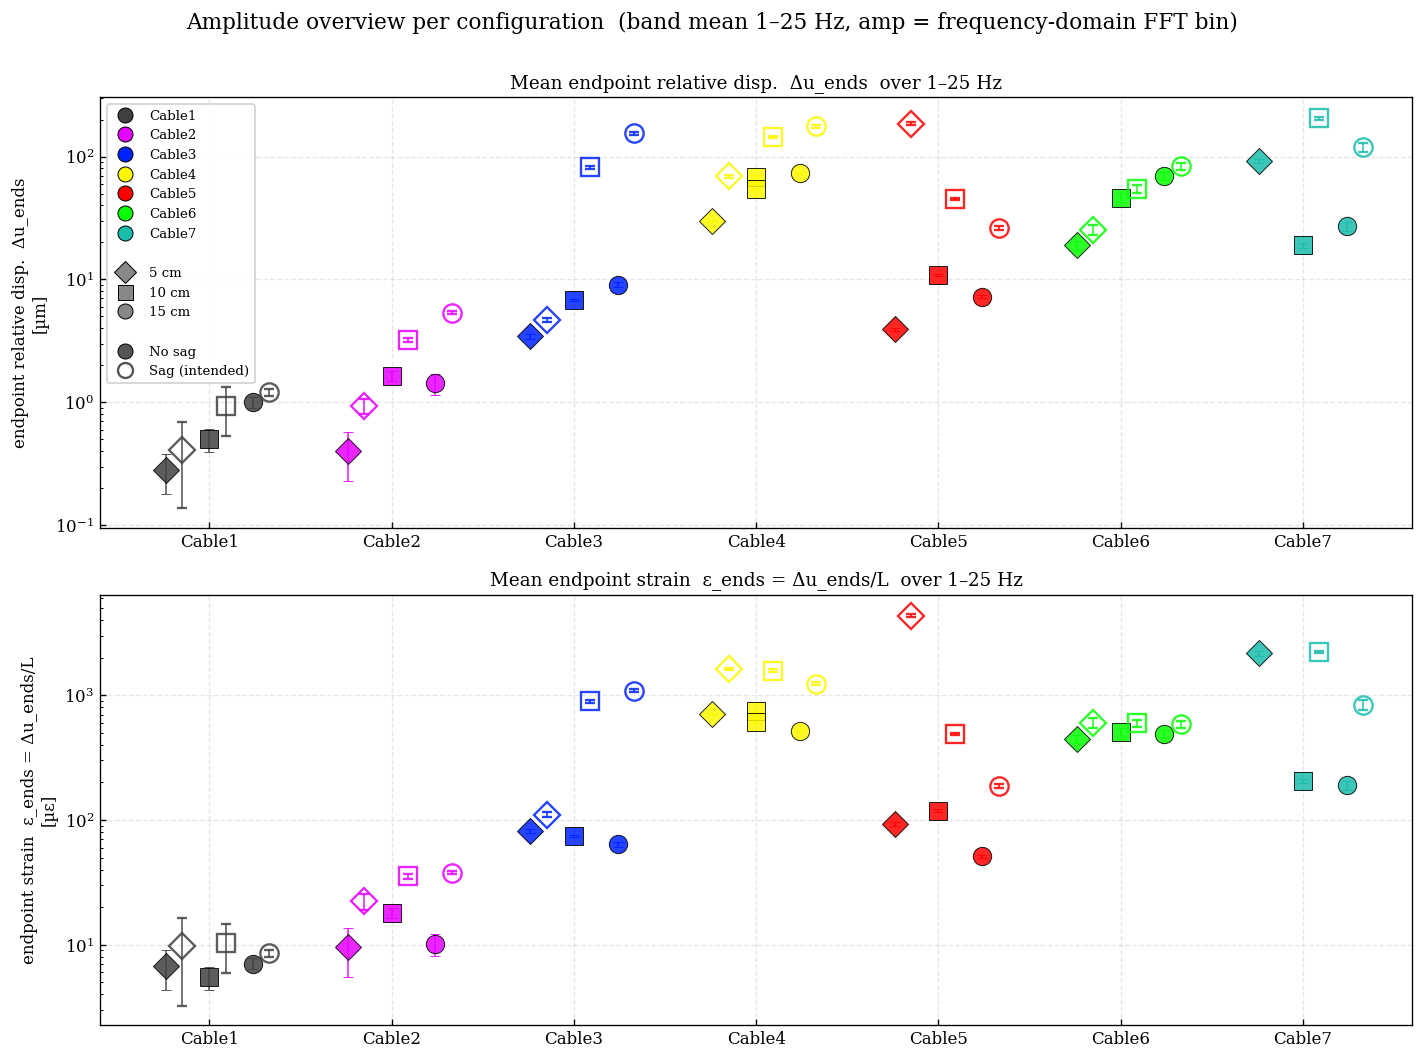

In [5]:
plotting.plot_amplitude_overview(
    DATASETS, f_min=F_MIN_LOW, f_max=F_MAX_LOW, amp_method=AMP_METHOD,
    quantities=('disp_ends', 'strain_ends'), logy=True, freqs=AMP_FREQS);

In [6]:
rows = []
for cfg in DATASETS:
    bm = amplitude.band_mean_amplitude(cfg, f_min=F_MIN_LOW, f_max=F_MAX_LOW,
                                       amp_method=AMP_METHOD)
    rows.append({
        'Label': cfg['label'], 'Cable': cfg.get('cable', '?'),
        'Gap [cm]': int(cfg['gap_m'] * 100),
        'Sag': 'yes' if 'Sag' in cfg['label'] else 'no',
        'Δu_ends [µm]': bm['disp_ends_mean'] * 1e6,
        'ε_ends [µε]': bm['strain_ends_mean'] * 1e6,
        'δL [µm]': bm['disp_shaker_mean'] * 1e6,
        'u_first [µm]': bm['disp_first_mean'] * 1e6,
        'T (sh→1)': bm['transfer_first_mean'],
    })
df_amp = (pd.DataFrame(rows)
          .sort_values(['Cable', 'Gap [cm]', 'Sag']).reset_index(drop=True))
df_amp.style.format({'Δu_ends [µm]': '{:.3f}', 'ε_ends [µε]': '{:.1f}',
                     'δL [µm]': '{:.3f}', 'u_first [µm]': '{:.3f}',
                     'T (sh→1)': '{:.3f}'})

,Label,Cable,Gap [cm],Sag,Δu_ends [µm],ε_ends [µε],δL [µm],u_first [µm],T (sh→1)
0,Cable1_5cm,Cable1,5,no,0.282,6.7,0.682,0.640,0.942
1,Cable1_5cm_Sag,Cable1,5,yes,0.413,9.8,0.925,0.834,0.904
2,Cable1_10cm,Cable1,10,no,0.501,5.5,0.975,0.846,0.924
3,Cable1_10cm_Sag,Cable1,10,yes,0.940,10.3,1.833,1.230,0.673
4,Cable1_15cm,Cable1,15,no,0.999,7.1,15.883,2.081,0.131
5,Cable1_15cm_Sag,Cable1,15,yes,1.207,8.5,8.422,2.038,0.243
6,Cable2_5cm,Cable2,5,no,0.405,9.6,2.323,1.022,0.441
7,Cable2_5cm_Sag,Cable2,5,yes,0.941,22.3,6.441,1.649,0.256
8,Cable2_10cm,Cable2,10,no,1.648,18.1,12.444,2.924,0.235
9,Cable2_10cm_Sag,Cable2,10,yes,3.219,35.3,19.125,4.669,0.244


---
## § 4  Amplitude vs frequency (all configs overlaid)

In [7]:
plotting.plot_amplitude_vs_frequency(
    DATASETS, quantity='strain_ends', amp_method=AMP_METHOD, freqs=AMP_FREQS)

# Interactive per-configuration viewer:
widgets.amplitude_browser(DATASETS, amp_method=AMP_METHOD, freqs=AMP_FREQS)

---
## § 5  Shaker input vs first cable sensor

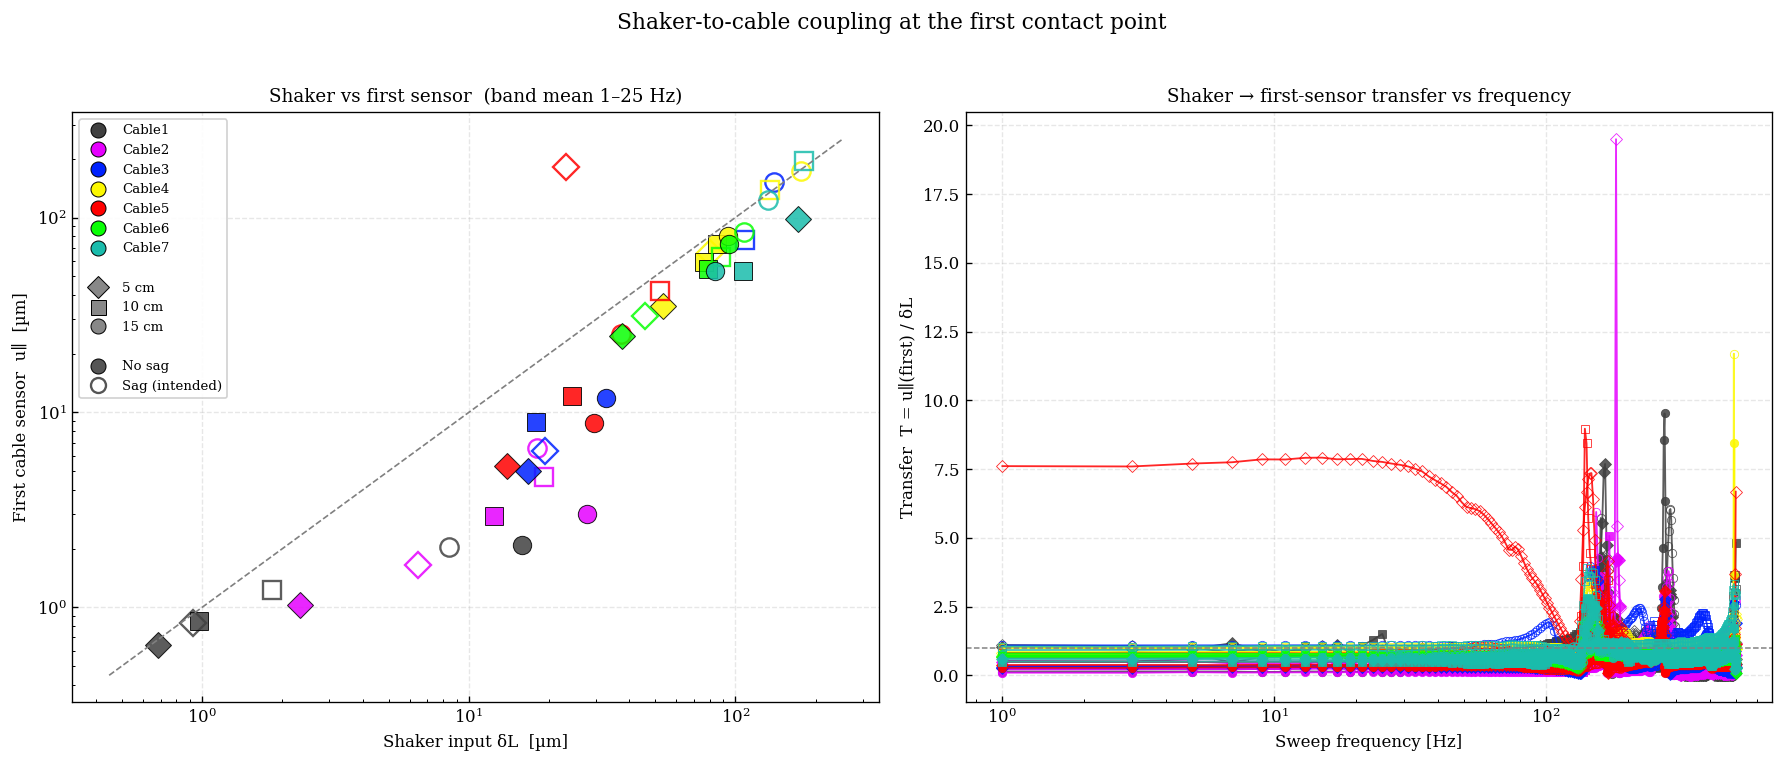

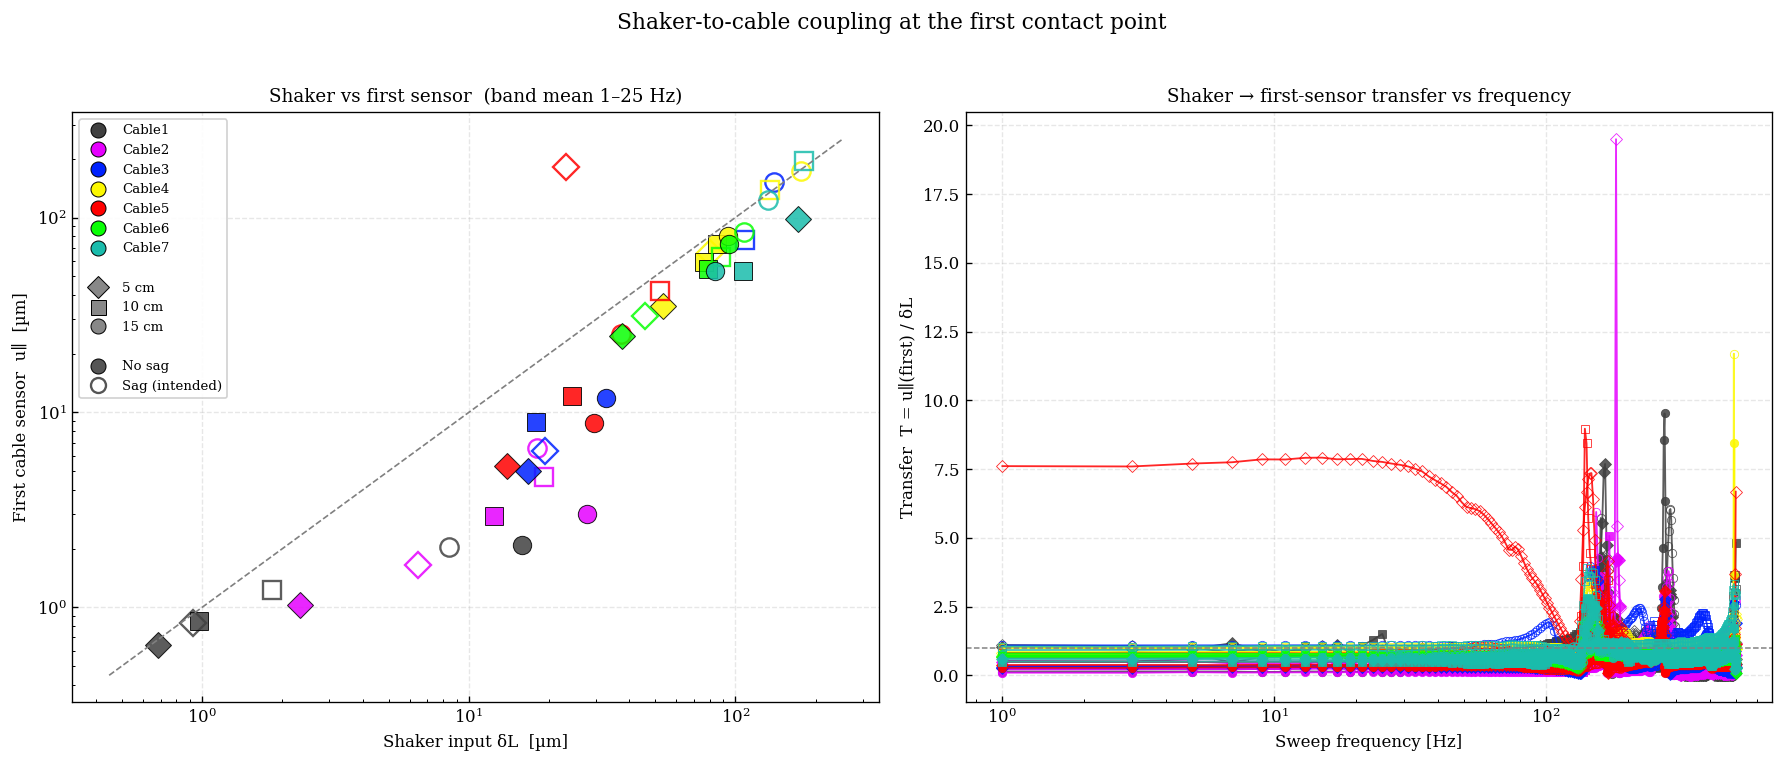

In [8]:
plotting.plot_shaker_transfer(
    DATASETS, f_min=F_MIN_LOW, f_max=F_MAX_LOW, amp_method=AMP_METHOD,
    freqs=AMP_FREQS);

---
## § 6  Extension vs compression asymmetry

Numerical simulations predict a different response when the endpoints move
**apart** (extension — sag straightens, stiffening) vs **together**
(compression — sag deepens, softening). Three detectors
(`ldv_analysis/asymmetry.py`):

1. **Half-cycle conditional η** — split samples by the sign of the endpoint
   elongation δ_ref(t): η_ext = median η over δ_ref > 0, η_comp over
   δ_ref < 0. Linear response ⇒ η_ext = η_comp.
2. **Peak asymmetry** α = (A₊ − A₋)/(A₊ + A₋) of the cable elongation δxₗ(t).
3. **Even-harmonic ratio** |Y(2f)|/|Y(f)| — a quadratic (sign-asymmetric)
   stiffness term puts energy at 2f; the cubic (symmetric) term at 3f is
   shown for attribution.

> The window pipeline is the time-domain one (bandpass ± 5 Hz), so the 2f
> harmonic of the *detection* is read from the unfiltered windowed elongation
> — the harmonic reader re-FFTs the window and looks at 2f directly.

asymmetry sweeps done.


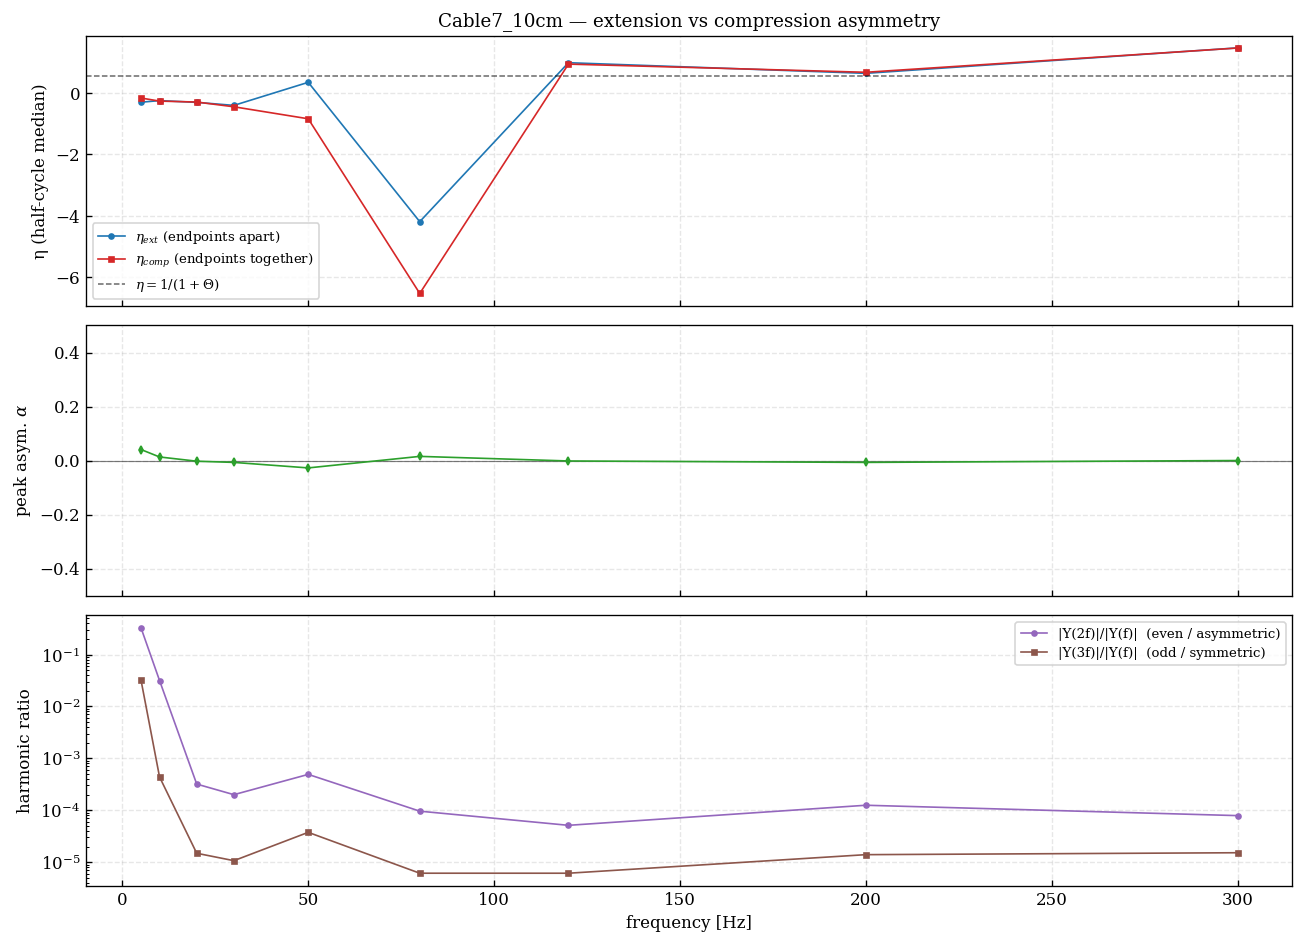

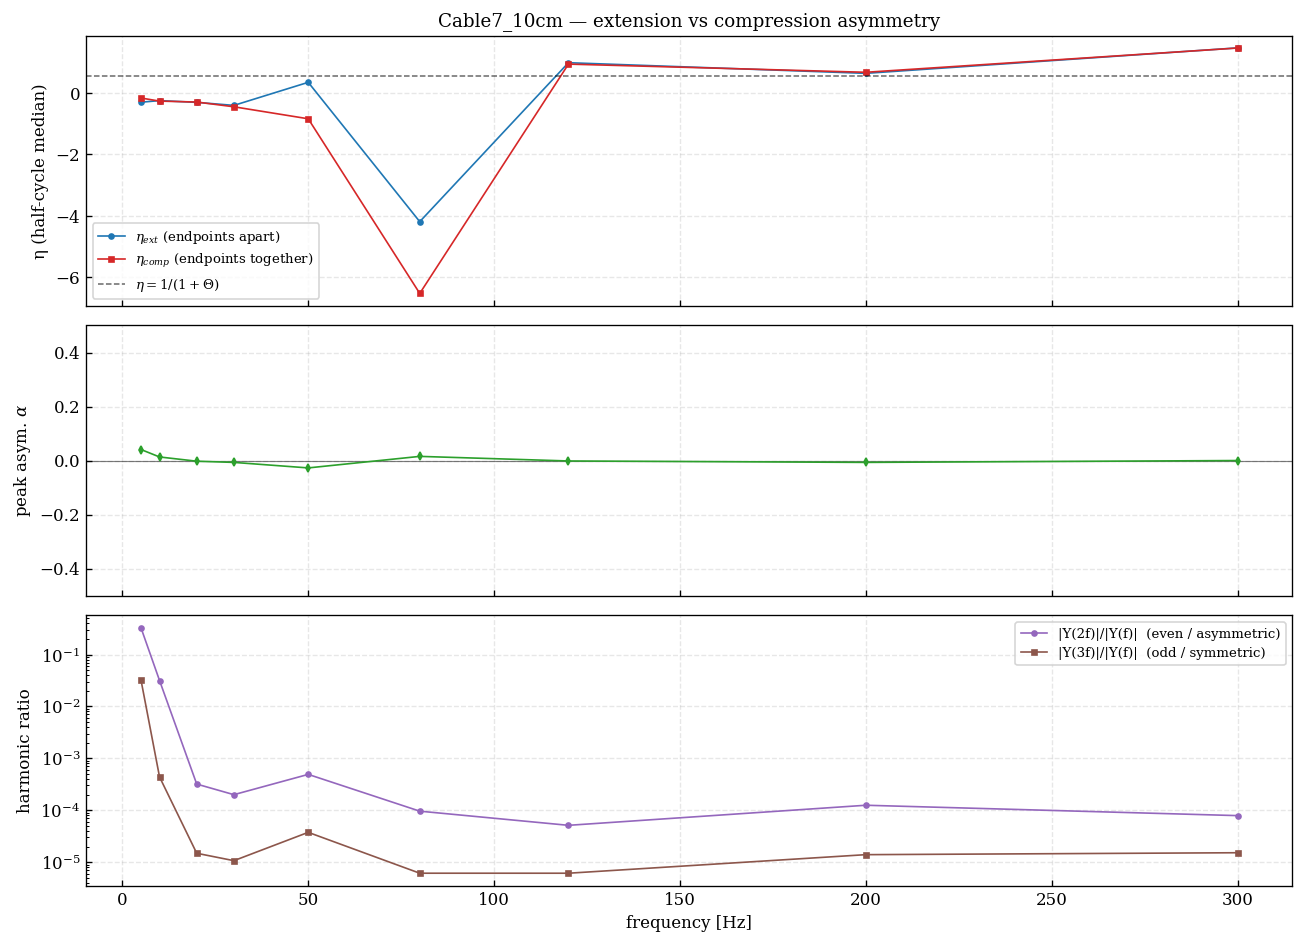

In [15]:
ASYM_FREQS = [5, 10, 20, 30, 50, 80, 120, 200, 300]

for cfg in DATASETS:
    asymmetry.asymmetry_sweep(cfg, freqs=ASYM_FREQS)
print("asymmetry sweeps done.")

# Per-dataset detail — edit DETAIL_IDX (clamped to the current selection):
DETAIL_IDX = 38
plotting.plot_asymmetry_sweep(DATASETS[min(DETAIL_IDX, len(DATASETS) - 1)],
                              f_max=320);

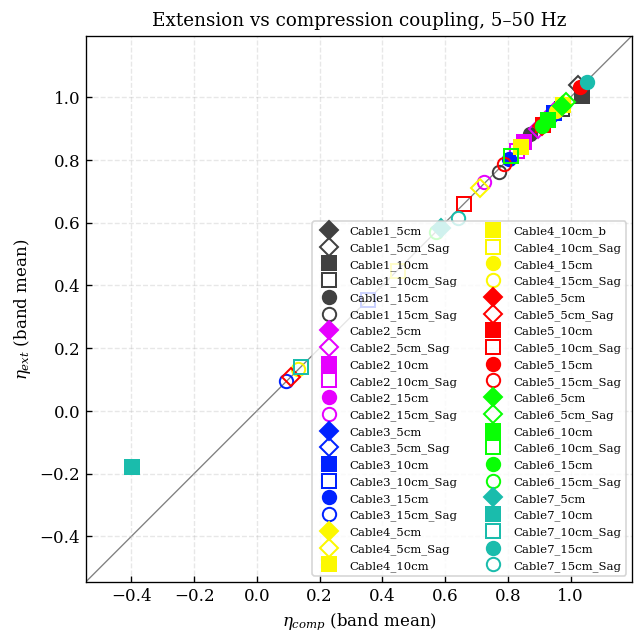

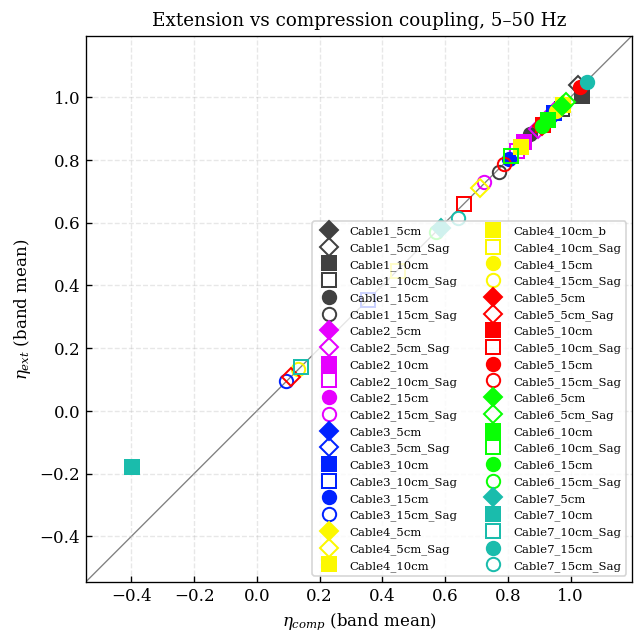

In [16]:
# Cross-configuration comparison: band-mean eta_ext vs eta_comp
plotting.plot_asymmetry_overview(DATASETS, f_min=5.0, f_max=50.0);

---
## § 7  Export

In [17]:
sw0 = DATASETS[0]['amp_sweep'][AMP_METHOD]
export.export_results(
    'amplitude_reference',
    meta=dict(band=(F_MIN_LOW, F_MAX_LOW), amp_method=AMP_METHOD),
    labels=[c['label'] for c in DATASETS],
    cable=[c['cable'] for c in DATASETS],
    gap_m=[c['gap_m'] for c in DATASETS],
    is_sag_variant=np.array(['Sag' in c['label'] for c in DATASETS]),
    f=sw0['f'],
    disp_ends=[c['amp_sweep'][AMP_METHOD]['disp_ends'] for c in DATASETS],
    strain_ends=[c['amp_sweep'][AMP_METHOD]['strain_ends'] for c in DATASETS],
    disp_shaker=[c['amp_sweep'][AMP_METHOD]['disp_shaker'] for c in DATASETS],
    disp_first=[c['amp_sweep'][AMP_METHOD]['disp_first'] for c in DATASETS],
    transfer_first=[c['amp_sweep'][AMP_METHOD]['transfer_first'] for c in DATASETS],
)

export.export_results(
    'asymmetry',
    meta=dict(freqs=ASYM_FREQS),
    labels=[c['label'] for c in DATASETS],
    cable=[c['cable'] for c in DATASETS],
    gap_m=[c['gap_m'] for c in DATASETS],
    f=[c['asym_sweep']['f'] for c in DATASETS],
    eta_ext=[c['asym_sweep']['eta_ext'] for c in DATASETS],
    eta_comp=[c['asym_sweep']['eta_comp'] for c in DATASETS],
    peak_asym=[c['asym_sweep']['peak_asym'] for c in DATASETS],
    h2_ratio=[c['asym_sweep']['h2_ratio'] for c in DATASETS],
    h3_ratio=[c['asym_sweep']['h3_ratio'] for c in DATASETS],
)

exported amplitude_reference.npz: labels(42,), cable(42,), gap_m(42,), is_sag_variant(42,), f(250,), disp_ends(42, 250), strain_ends(42, 250), disp_shaker(42, 250), disp_first(42, 250), transfer_first(42, 250)
exported asymmetry.npz: labels(42,), cable(42,), gap_m(42,), f(42, 9), eta_ext(42, 9), eta_comp(42, 9), peak_asym(42, 9), h2_ratio(42, 9), h3_ratio(42, 9)


WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/asymmetry.npz')